The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


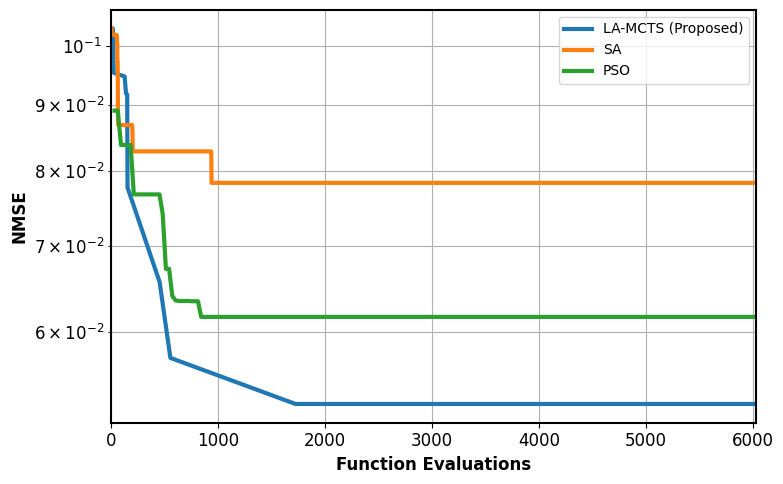

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# Load .mat file
data = loadmat("NMSE_convergence.mat")

# Extract variables (flatten because MATLAB saves as 2D)
call_marks = data["call_marks"].flatten()
best_fx = data["best_fx"].flatten()

sa_evals = data["sa_evals"].flatten()
sa_history = data["sa_history"].flatten()

pso_evals = data["pso_evals"].flatten()
pso_history = data["pso_history"].flatten()

max_evals = int(data["max_evals"].flatten()[0])

# --------------------------------------
# Optional: ensure monotonic convergence
# --------------------------------------
best_fx = np.minimum.accumulate(best_fx)
sa_history = np.minimum.accumulate(sa_history)
pso_history = np.minimum.accumulate(pso_history)

# --------------------------------------
# Plot
# --------------------------------------
plt.rcParams.update({
    "font.size": 12,
    "axes.labelweight": "bold",
    "axes.linewidth": 1.5,
})

plt.figure(figsize=(8, 5))

# LA-MCTS
plt.plot(call_marks, best_fx,
         linestyle='-',
         linewidth=3,
         label="LA-MCTS (Proposed)")

# SA
plt.plot(sa_evals, sa_history,
         linestyle='-',
         linewidth=3,
         label="SA")

# PSO
plt.plot(pso_evals, pso_history,
         linestyle='-',
         linewidth=3,
         label="PSO")

# --------------------------------------
# Formatting
# --------------------------------------
plt.xlabel("Function Evaluations", fontweight="bold")
plt.ylabel("NMSE", fontweight="bold")

plt.yscale("log")
plt.grid(True, which="both", linestyle='-', linewidth=0.8)

plt.legend(fontsize=10)

plt.xlim(0, max_evals)

plt.tight_layout()

# Save (paper-ready)
# Save (publication-ready formats)
plt.savefig("NMSE_convergence.pdf", format="pdf", dpi=300, bbox_inches="tight")

plt.savefig("NMSE_convergence.eps", format="eps", dpi=300, bbox_inches="tight")

plt.show()